<h1>Импорт библиотек

In [3]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [5]:
import numpy as np

def sum_prod(matrices, vectors):
    M = np.asarray(matrices)
    V = np.asarray(vectors)
    n = M.shape[1]
    if M.shape[2] != n or V.shape[1] != n or V.shape[2] != 1:
        raise ValueError("Несоответствие размерностей")
    return np.sum(M @ V, axis=0)

if __name__ == "__main__":
    M1 = np.array([[[1, 2], [3, 4]]])
    V1 = np.array([[[5], [6]]])
    assert np.array_equal(sum_prod(M1, V1), np.array([[17], [39]]))

    M2 = np.array([np.eye(3), 2*np.eye(3)])
    V2 = np.array([[[1],[2],[3]], [[4],[5],[6]]])
    assert np.array_equal(sum_prod(M2, V2), np.array([[9],[12],[15]]))

    M_list = [np.array([[1,0],[0,1]]), np.array([[0,1],[1,0]])]
    V_list = [np.array([[7],[8]]), np.array([[9],[10]])]
    assert np.array_equal(sum_prod(M_list, V_list), np.array([[17],[17]]))
    print("Все тесты пройдены!")

Все тесты пройдены!


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [7]:
import numpy as np

def binarize(M, threshold=0.5):
    M = np.asarray(M)
    return (M > threshold).astype(int)

if __name__ == "__main__":
    assert np.array_equal(binarize([[0.1, 0.8], [0.6, 0.3]], 0.5), np.array([[0, 1], [1, 0]]))
    assert np.array_equal(binarize([0.2, 0.9, 0.4]), np.array([0, 1, 0]))
    assert np.array_equal(binarize([[1, 2], [3, 4]], 2), np.array([[0, 0], [1, 1]]))
    print("Все тесты пройдены!")

Все тесты пройдены!


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [6]:
def unique_rows(mat):
    return [list(set(row)) for row in mat]

def unique_columns(mat):
    if not mat:
        return []
    rows = len(mat)
    cols = len(mat[0])
    result = []
    for j in range(cols):
        col = [mat[i][j] for i in range(rows)]
        result.append(list(set(col)))
    return result

if __name__ == "__main__":
    M = [[1, 2, 2], [3, 3, 4], [5, 6, 5]]
    assert unique_rows(M) == [[1, 2], [3, 4], [5, 6]]
    assert unique_columns(M) == [[1, 3, 5], [2, 3, 6], [2, 4, 5]]

    M2 = [[1, 1], [2, 2]]
    assert unique_rows(M2) == [[1], [2]]
    assert unique_columns(M2) == [[1, 2], [1, 2]]

    M3 = [[5]]
    assert unique_rows(M3) == [[5]]
    assert unique_columns(M3) == [[5]]

    print("Все тесты пройдены!")

Все тесты пройдены!


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

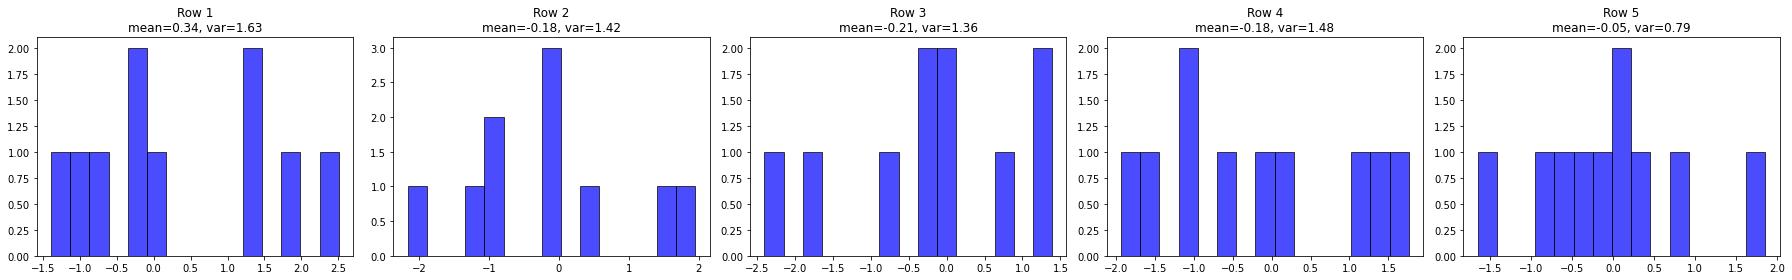

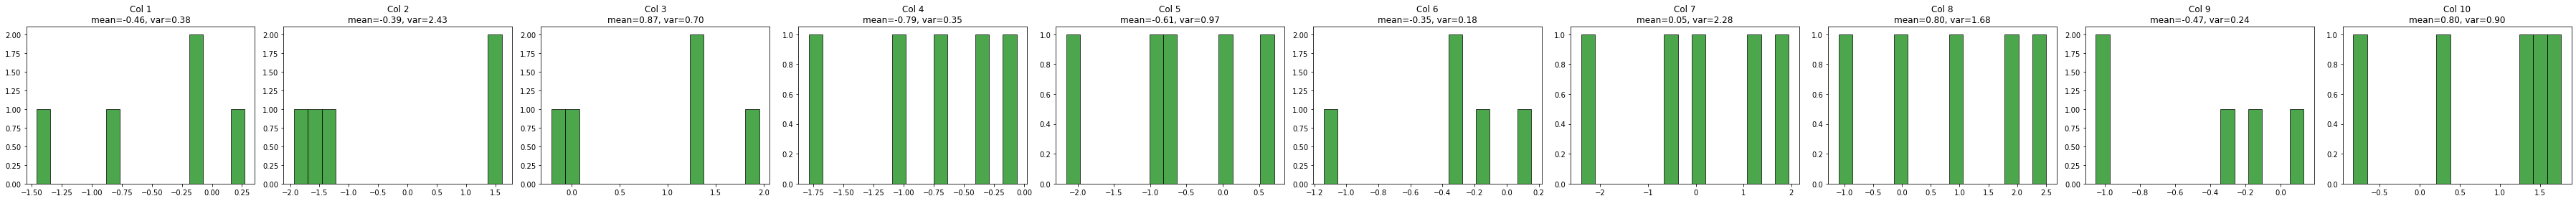

Тесты пройдены!


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def generate_and_analyze(m, n, mean=0, std=1):
    M = np.random.normal(mean, std, (m, n))
    rm, rv = M.mean(1), M.var(1)
    cm, cv = M.mean(0), M.var(0)
    for i, data in enumerate([(M, rm, rv, 'Row', 'blue', m), (M.T, cm, cv, 'Col', 'green', n)]):
        mat, means, vars_, label, color, k = data
        fig, axes = plt.subplots(1, k, figsize=(5*k, 4))
        if k == 1: axes = [axes]
        for j in range(k):
            axes[j].hist(mat[j], bins=15, alpha=0.7, color=color, edgecolor='black')
            axes[j].set_title(f'{label} {j+1}\nmean={means[j]:.2f}, var={vars_[j]:.2f}')
        plt.tight_layout(); plt.show()
    return M, rm, rv, cm, cv

def test():
    m, n = 5, 10
    M, rm, rv, cm, cv = generate_and_analyze(m, n)
    assert M.shape == (m, n) and len(rm)==m and len(rv)==m and len(cm)==n and len(cv)==n
    assert np.allclose(rm, M.mean(1)) and np.allclose(rv, M.var(1))
    assert np.allclose(cm, M.mean(0)) and np.allclose(cv, M.var(0))
    print("Тесты пройдены!")

if __name__ == "__main__":
    test()

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [10]:
import numpy as np

def chess(m, n, a, b):
    matrix = np.zeros((m, n), dtype=type(a))
    for i in range(m):
        for j in range(n):
            matrix[i, j] = a if (i + j) % 2 == 0 else b
    return matrix

if __name__ == "__main__":
    assert np.array_equal(chess(1, 1, 1, 0), np.array([[1]]))
    expected = np.array([[1, 0], [0, 1]])
    assert np.array_equal(chess(2, 2, 1, 0), expected)
    expected = np.array([[5, -5, 5], [-5, 5, -5], [5, -5, 5]])
    assert np.array_equal(chess(3, 3, 5, -5), expected)
    print("Все тесты пройдены!")

Все тесты пройдены!


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

In [1]:
import numpy as np

def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    x0, y0 = n // 2, m // 2
    x1 = max(0, x0 - a // 2)
    x2 = min(n, x0 + a // 2)
    y1 = max(0, y0 - b // 2)
    y2 = min(m, y0 + b // 2)
    img[y1:y2, x1:x2] = rectangle_color
    return img

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    x0, y0 = n // 2, m // 2
    for y in range(m):
        for x in range(n):
            if ((x - x0) ** 2) / (a ** 2) + ((y - y0) ** 2) / (b ** 2) <= 1:
                img[y, x] = ellipse_color
    return img

if __name__ == "__main__":
    rect = draw_rectangle(4, 3, 5, 5, [255,0,0], [0,0,0])
    assert rect.shape == (5,5,3)
    assert np.array_equal(rect[2,2], [255,0,0])
    assert np.array_equal(rect[0,0], [0,0,0])

    ellipse = draw_ellipse(2, 1, 5, 5, [0,255,0], [0,0,0])
    assert ellipse.shape == (5,5,3)
    assert np.array_equal(ellipse[2,2], [0,255,0])
    assert np.array_equal(ellipse[0,0], [0,0,0])

    print("Все тесты пройдены!")

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [15]:
import numpy as np

def analyze_timeseries(series, p):
    series = np.array(series)
    mean = np.mean(series)
    variance = np.var(series)          
    std = np.std(series)               
    maxima = []
    minima = []
    for i in range(1, len(series) - 1):
        if series[i] > series[i-1] and series[i] > series[i+1]:
            maxima.append((i, series[i]))
        elif series[i] < series[i-1] and series[i] < series[i+1]:
            minima.append((i, series[i]))
    moving_avg = np.convolve(series, np.ones(p)/p, mode='valid')
    return mean, variance, std, maxima, minima, moving_avg

def test_analyze_timeseries():
    series = [1, 3, 2, 5, 4, 2, 6, 1]
    mean, var, std, maxima, minima, ma = analyze_timeseries(series, 3)
    assert abs(mean - 3.0) < 1e-9
    assert abs(var - 3.0) < 1e-9          
    assert abs(std - np.sqrt(3.0)) < 1e-9
    assert maxima == [(1, 3), (3, 5), (6, 6)]
    assert minima == [(2, 2), (4, 4), (7, 1)]
    expected_ma = [(1+3+2)/3, (3+2+5)/3, (2+5+4)/3, (5+4+2)/3, (4+2+6)/3, (2+6+1)/3]
    assert np.allclose(ma, expected_ma)

    series2 = [1, 1, 1, 1]
    mean2, var2, std2, max2, min2, ma2 = analyze_timeseries(series2, 2)
    assert mean2 == 1
    assert var2 == 0
    assert max2 == []
    assert min2 == []
    assert np.allclose(ma2, [1, 1, 1])

    print("Все тесты пройдены!")

if __name__ == "__main__":
    test_analyze_timeseries()

AssertionError: 

<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [ ]:
# Your code goes here